In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = True
plt.style.use('seaborn-v0_8-colorblind')

'2.2.5'

In [2]:
results = pd.read_csv("results.csv")
df = results[results['State'] == 'finished']
df = df[
    ["model.name", "model.aggregation", "model.alpha_scalar", "dataset.modalities_order"] + [col for col in df.columns if "final_scores" in col] 
] 
df.head()

,model.name,model.aggregation,model.alpha_scalar,dataset.modalities_order,final_scores/coherence/m0_to_m0,final_scores/coherence/m0_to_m0_cov,final_scores/coherence/m0_to_m1,final_scores/coherence/m0_to_m1_cov,final_scores/coherence/m0_to_m2,final_scores/coherence/m0_to_m2_cov,...,final_scores/downstream_lr/aggregated/m1,final_scores/downstream_lr/aggregated/m2,final_scores/downstream_lr/aggregated/m3,final_scores/downstream_lr/aggregated/m4,final_scores/downstream_lr/unimodal/m0,final_scores/downstream_lr/unimodal/m1,final_scores/downstream_lr/unimodal/m2,final_scores/downstream_lr/unimodal/m3,final_scores/downstream_lr/unimodal/m4,final_scores/rec_loss
0,jointprior,avg,0.97,4,0.883614,0.883614,0.122496,0.717248,0.133213,0.730769,...,0.966647,0.970553,0.957031,0.978666,0.956130,0.966647,0.970553,0.957031,0.978666,5444.293945
1,jointprior,avg,0.97,3,0.880709,0.880809,0.115184,0.751102,0.125000,0.748297,...,0.967849,0.971454,0.982873,0.964944,0.953225,0.967849,0.971454,0.982873,0.964944,5444.096191
2,jointprior,avg,0.97,1,0.882812,0.883013,0.054888,0.744591,0.123097,0.736078,...,0.989183,0.973558,0.957532,0.964643,0.950721,0.989183,0.973558,0.957532,0.964643,5441.731445
3,jointprior,avg,0.97,2,0.879207,0.879107,0.113682,0.710437,0.051282,0.734776,...,0.968349,0.989083,0.956631,0.964343,0.957532,0.968349,0.989083,0.956631,0.964343,5444.194824
4,jointprior,avg,0.97,4,0.878706,0.878706,0.149038,0.735877,0.114483,0.723758,...,0.966046,0.969752,0.956430,0.978065,0.955929,0.966046,0.969752,0.956430,0.978065,5441.833008


Update names.

In [3]:
old_name = df['model.name'] + df['model.aggregation']
new_name = old_name.str.replace("jointavg", "AVG", regex=False)
new_name = new_name.str.replace("jointprior", "JP", regex=False)
new_name = new_name.str.replace("joint", "", regex=False)
new_name = new_name.str.replace("avg", "", regex=False)
new_name = new_name.str.replace("moe", "MoE", regex=False)
new_name = new_name.str.replace("mopoe", "MoPoE", regex=False)
new_name = new_name.str.replace("mixedprior", "MMVM", regex=False)
new_name = new_name.str.replace("unimodal", "independent", regex=False)
df.loc[:, 'model.name'] = new_name
df.head()

,model.name,model.aggregation,model.alpha_scalar,dataset.modalities_order,final_scores/coherence/m0_to_m0,final_scores/coherence/m0_to_m0_cov,final_scores/coherence/m0_to_m1,final_scores/coherence/m0_to_m1_cov,final_scores/coherence/m0_to_m2,final_scores/coherence/m0_to_m2_cov,...,final_scores/downstream_lr/aggregated/m1,final_scores/downstream_lr/aggregated/m2,final_scores/downstream_lr/aggregated/m3,final_scores/downstream_lr/aggregated/m4,final_scores/downstream_lr/unimodal/m0,final_scores/downstream_lr/unimodal/m1,final_scores/downstream_lr/unimodal/m2,final_scores/downstream_lr/unimodal/m3,final_scores/downstream_lr/unimodal/m4,final_scores/rec_loss
0,JP,avg,0.97,4,0.883614,0.883614,0.122496,0.717248,0.133213,0.730769,...,0.966647,0.970553,0.957031,0.978666,0.956130,0.966647,0.970553,0.957031,0.978666,5444.293945
1,JP,avg,0.97,3,0.880709,0.880809,0.115184,0.751102,0.125000,0.748297,...,0.967849,0.971454,0.982873,0.964944,0.953225,0.967849,0.971454,0.982873,0.964944,5444.096191
2,JP,avg,0.97,1,0.882812,0.883013,0.054888,0.744591,0.123097,0.736078,...,0.989183,0.973558,0.957532,0.964643,0.950721,0.989183,0.973558,0.957532,0.964643,5441.731445
3,JP,avg,0.97,2,0.879207,0.879107,0.113682,0.710437,0.051282,0.734776,...,0.968349,0.989083,0.956631,0.964343,0.957532,0.968349,0.989083,0.956631,0.964343,5444.194824
4,JP,avg,0.97,4,0.878706,0.878706,0.149038,0.735877,0.114483,0.723758,...,0.966046,0.969752,0.956430,0.978065,0.955929,0.966046,0.969752,0.956430,0.978065,5441.833008


Generate new columns of averages.

In [5]:
views = ["m0", "m1", "m2", "m3", "m4"]
relationships = []
indiv_results = []
one_to_one = []
column_names = []
for view_a in views:
  view_a_list = []
  one_to_one.append(view_a + "_to_" + view_a)
  for view_b in views:
    relationships.append(view_a + "_to_" + view_b)
    if view_a != view_b:
      view_a_list.append(view_b + "_to_" + view_a)
  indiv_results.append(view_a_list) # store view_a list
  column_names.append(str(view_a))
  indiv_results.append([view + "_cov" for view in view_a_list])
  column_names.append(str(view_a) + "_cov")
    
indiv_results.append(one_to_one)
column_names.append("one_to_one")
indiv_results.append([rel + "_cov" for rel in one_to_one])
column_names.append("one_to_one_cov")

# calculate averages
for i, cols in enumerate(indiv_results): 
  df[column_names[i]] = df[["final_scores/coherence/" + rel for rel in cols]].mean(axis=1)

df.head()

,model.name,model.aggregation,model.alpha_scalar,dataset.modalities_order,final_scores/coherence/m0_to_m0,final_scores/coherence/m0_to_m0_cov,final_scores/coherence/m0_to_m1,final_scores/coherence/m0_to_m1_cov,final_scores/coherence/m0_to_m2,final_scores/coherence/m0_to_m2_cov,...,m1,m1_cov,m2,m2_cov,m3,m3_cov,m4,m4_cov,one_to_one,one_to_one_cov
0,JP,avg,0.97,4,0.883614,0.883614,0.122496,0.717248,0.133213,0.730769,...,0.096680,0.834560,0.099584,0.843274,0.094827,0.755884,0.074745,0.590570,0.944892,0.944912
1,JP,avg,0.97,3,0.880709,0.880809,0.115184,0.751102,0.125000,0.748297,...,0.093249,0.834936,0.100861,0.830604,0.072917,0.677284,0.098733,0.534080,0.940064,0.940164
2,JP,avg,0.97,1,0.882812,0.883013,0.054888,0.744591,0.123097,0.736078,...,0.064328,0.802860,0.106846,0.812901,0.093500,0.777920,0.099609,0.531751,0.940325,0.940385
3,JP,avg,0.97,2,0.879207,0.879107,0.113682,0.710437,0.051282,0.734776,...,0.095378,0.804312,0.068485,0.802684,0.095578,0.730494,0.096229,0.604542,0.939223,0.939163
4,JP,avg,0.97,4,0.878706,0.878706,0.149038,0.735877,0.114483,0.723758,...,0.096329,0.841647,0.093725,0.840946,0.095653,0.665390,0.075270,0.431691,0.943690,0.943670


In [6]:
df["dataset.modalities_order"] = [int(res[0]) if len(res) == 1 else 
                                           int(res[1]) for res in df["dataset.modalities_order"].fillna('0')]
df.head()

,model.name,model.aggregation,model.alpha_scalar,dataset.modalities_order,final_scores/coherence/m0_to_m0,final_scores/coherence/m0_to_m0_cov,final_scores/coherence/m0_to_m1,final_scores/coherence/m0_to_m1_cov,final_scores/coherence/m0_to_m2,final_scores/coherence/m0_to_m2_cov,...,m1,m1_cov,m2,m2_cov,m3,m3_cov,m4,m4_cov,one_to_one,one_to_one_cov
0,JP,avg,0.97,4,0.883614,0.883614,0.122496,0.717248,0.133213,0.730769,...,0.096680,0.834560,0.099584,0.843274,0.094827,0.755884,0.074745,0.590570,0.944892,0.944912
1,JP,avg,0.97,3,0.880709,0.880809,0.115184,0.751102,0.125000,0.748297,...,0.093249,0.834936,0.100861,0.830604,0.072917,0.677284,0.098733,0.534080,0.940064,0.940164
2,JP,avg,0.97,1,0.882812,0.883013,0.054888,0.744591,0.123097,0.736078,...,0.064328,0.802860,0.106846,0.812901,0.093500,0.777920,0.099609,0.531751,0.940325,0.940385
3,JP,avg,0.97,2,0.879207,0.879107,0.113682,0.710437,0.051282,0.734776,...,0.095378,0.804312,0.068485,0.802684,0.095578,0.730494,0.096229,0.604542,0.939223,0.939163
4,JP,avg,0.97,4,0.878706,0.878706,0.149038,0.735877,0.114483,0.723758,...,0.096329,0.841647,0.093725,0.840946,0.095653,0.665390,0.075270,0.431691,0.943690,0.943670


Subset the relevant datasets:

Add a column indicating the rate at which the covariance based imputation approach gives better results than the standard approach. 

In [8]:
relationships_full = ["final_scores/coherence/" + rel for rel in relationships]
cov_better = []
for rel in relationships_full:
  cov_better.append((df[rel] < df[rel + "_cov"]))

df['cov_better'] = np.mean(np.array(cov_better), axis = 0)
df.head()

,model.name,model.aggregation,model.alpha_scalar,dataset.modalities_order,final_scores/coherence/m0_to_m0,final_scores/coherence/m0_to_m0_cov,final_scores/coherence/m0_to_m1,final_scores/coherence/m0_to_m1_cov,final_scores/coherence/m0_to_m2,final_scores/coherence/m0_to_m2_cov,...,m1_cov,m2,m2_cov,m3,m3_cov,m4,m4_cov,one_to_one,one_to_one_cov,cov_better
0,JP,avg,0.97,4,0.883614,0.883614,0.122496,0.717248,0.133213,0.730769,...,0.834560,0.099584,0.843274,0.094827,0.755884,0.074745,0.590570,0.944892,0.944912,0.84
1,JP,avg,0.97,3,0.880709,0.880809,0.115184,0.751102,0.125000,0.748297,...,0.834936,0.100861,0.830604,0.072917,0.677284,0.098733,0.534080,0.940064,0.940164,0.96
2,JP,avg,0.97,1,0.882812,0.883013,0.054888,0.744591,0.123097,0.736078,...,0.802860,0.106846,0.812901,0.093500,0.777920,0.099609,0.531751,0.940325,0.940385,0.88
3,JP,avg,0.97,2,0.879207,0.879107,0.113682,0.710437,0.051282,0.734776,...,0.804312,0.068485,0.802684,0.095578,0.730494,0.096229,0.604542,0.939223,0.939163,0.80
4,JP,avg,0.97,4,0.878706,0.878706,0.149038,0.735877,0.114483,0.723758,...,0.841647,0.093725,0.840946,0.095653,0.665390,0.075270,0.431691,0.943690,0.943670,0.80


Great a dataframe of the averages over results

In [9]:
metric_cols = [c for c in df.columns if "final_scores/coherence/m" in c]
metric_cols_cov = [c for c in metric_cols if "cov" in c]
metric_cols = [c for c in metric_cols if "cov" not in c]

In [177]:
df_subset = df.fillna(-1)
df_subset.loc[df_subset['model.name']== 'independent', 'model.alpha_scalar'] = 0
df_subset = df_subset[df_subset["model.alpha_scalar"] != -1]
df_subset['model.name'] = df_subset['model.name'] + ["-" + str(x) for x in df_subset['model.alpha_scalar']]
df_subset['model.name'] = [str(x) for x in df_subset['model.alpha_scalar']]
df_subset = df_subset[df_subset["dataset.modalities_order"] == 0]
model_means_jp = df_subset.groupby("model.name")[metric_cols].mean()
model_means_jp_cov = df_subset.groupby("model.name")[metric_cols_cov].mean()
model_means_jp

,final_scores/coherence/m0_to_m0,final_scores/coherence/m0_to_m1,final_scores/coherence/m0_to_m2,final_scores/coherence/m0_to_m3,final_scores/coherence/m0_to_m4,final_scores/coherence/m1_to_m0,final_scores/coherence/m1_to_m1,final_scores/coherence/m1_to_m2,final_scores/coherence/m1_to_m3,final_scores/coherence/m1_to_m4,...,final_scores/coherence/m3_to_m0,final_scores/coherence/m3_to_m1,final_scores/coherence/m3_to_m2,final_scores/coherence/m3_to_m3,final_scores/coherence/m3_to_m4,final_scores/coherence/m4_to_m0,final_scores/coherence/m4_to_m1,final_scores/coherence/m4_to_m2,final_scores/coherence/m4_to_m3,final_scores/coherence/m4_to_m4
model.name,,,,,,,,,,,,,,,,,,,,,
0.0,0.808093,0.096695,0.097336,0.100541,0.101963,0.101703,0.963401,0.101322,0.101502,0.099038,...,0.101783,0.106691,0.101743,0.959595,0.102003,0.100240,0.100481,0.100220,0.098417,0.871194
0.1,0.826482,0.099920,0.099940,0.098638,0.098197,0.101863,0.965084,0.098377,0.095493,0.101382,...,0.101342,0.099419,0.103526,0.959355,0.099399,0.100861,0.099499,0.103185,0.099740,0.870152
0.3,0.858594,0.092027,0.093590,0.089864,0.094311,0.096675,0.965745,0.096274,0.096875,0.103225,...,0.099239,0.104788,0.101122,0.960076,0.099159,0.099018,0.100942,0.102163,0.097917,0.873117
0.5,0.880228,0.075501,0.080008,0.076903,0.082071,0.096554,0.966446,0.101803,0.097416,0.102885,...,0.096254,0.101042,0.101502,0.960637,0.098658,0.094692,0.104107,0.104347,0.097456,0.878766
0.7,0.894451,0.068129,0.066647,0.063121,0.076122,0.093049,0.968249,0.102023,0.097616,0.105128,...,0.094531,0.098057,0.098257,0.962059,0.098738,0.090885,0.107792,0.103946,0.097676,0.891266
0.9,0.907492,0.054287,0.056811,0.047175,0.061939,0.092648,0.969191,0.099960,0.102444,0.109215,...,0.089243,0.105589,0.099299,0.963882,0.103486,0.091446,0.120172,0.105148,0.103265,0.900260
0.93,0.909014,0.049960,0.056250,0.042548,0.062780,0.090284,0.970493,0.110817,0.103425,0.108734,...,0.087981,0.106210,0.100461,0.964403,0.106190,0.088041,0.121695,0.103706,0.107292,0.901783
0.95,0.908794,0.045172,0.047456,0.043550,0.066126,0.089403,0.969872,0.102925,0.098738,0.108313,...,0.085657,0.103806,0.114663,0.964243,0.108714,0.086118,0.121034,0.110998,0.110256,0.902584
0.97,0.912099,0.044311,0.051322,0.038602,0.062821,0.088502,0.970393,0.111018,0.102284,0.111819,...,0.084475,0.109115,0.109696,0.965505,0.110256,0.088301,0.124319,0.110096,0.114844,0.905389


## $\alpha$ tuning

### Functions


In [178]:

def extract_matrix(avg_series, cov=False):
    """Convert a row of averaged metrics into a square DataFrame."""
    tmp = avg_series.to_frame("value")
    if cov == False:
      ex = tmp.index.to_series().str.extract(r"m(\d+)_to_m(\d+)")
    else:
      ex = tmp.index.to_series().str.extract(r"m(\d+)_to_m(\d+)_cov")
    tmp["from"]   = "M" + ex[0].astype(str)
    tmp["to"] = "M" + ex[1].astype(str)
    tmp = tmp.dropna(subset=["to", "from"])
    return tmp.pivot(index="to", columns="from", values="value")

def produce_plots(matrices, filename, v_min=0, color_map='viridis', text_color='w', n_cols=0, n_rows=0, bottom=0):
  n_models = len(matrices)
  if n_cols == 0 :
    n_cols = min(3, n_models)  # up to 3 per row
    n_rows = int(np.ceil(n_models / n_cols))
  
  fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
  axes = np.array(axes).reshape(-1)  # flatten in case of 1 row
  # fig.delaxes(axes.flatten()[8])
  # fig.delaxes(axes.flatten()[11])
  for ax, (name, mat) in zip(axes, matrices.items()):
      if type(mat) == int:
        ax.axis("off")
        continue
      data = mat.values
      im = ax.imshow(data, cmap=color_map, vmin=v_min, vmax=1, interpolation='none')
      # ax.grid(None)
      ax.grid(visible=False)
      ax.set_title(f"{name}", fontsize=12)
      ax.set_xlabel("From")
      ax.set_ylabel("To")
      ax.set_xticks(np.arange(len(mat.columns)))
      ax.set_yticks(np.arange(len(mat.index)))
      ax.set_xticklabels(mat.columns)
      ax.set_yticklabels(mat.index)
      plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
      
      # Annotate cells
      for i in range(len(mat.index)):
          for j in range(len(mat.columns)):
              ax.text(j, i, f"{data[i, j]:.2f}", ha="center", va="center", color=text_color, fontsize=8)

  # Add a shared colorbar
  cbar = fig.colorbar(im, ax=axes, orientation='horizontal', fraction=0.05, pad=0.08, aspect=30)
  cbar.ax.set_position([0.3, bottom, 0.4, 0.03])  # [left, bottom, width, height]
  # cbar.ax.set_position([0.5, 0.2, 0.4, 0.03])  # [left, bottom, width, height]

  # Hide unused subplots (if any)
  for ax in axes[len(matrices):]:
      ax.axis("off")
      ax.grid(visible=False)
  
  plt.subplots_adjust(wspace=-0.2, hspace=0.35)
  # plt.tight_layout(rect=[0, 0.08, 1, 1])  
  # plt.tight_layout()
  plt.savefig(filename, bbox_inches='tight')
  plt.show()

In [179]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

def produce_alpha_plots(matrices, filename, v_min=0, color_map='viridis', text_color='w', n_rows=3, n_cols=4):
    """
    Plot up to 10 heatmaps on a 3x4 grid, with the last two centered on the bottom row.
    Unused subplots are hidden.
    """
    n_models = len(matrices)
    
    fig = plt.figure(figsize=(5*n_cols, 4*n_rows))
    gs = gridspec.GridSpec(n_rows, n_cols, figure=fig, wspace=-0.4, hspace=0.35)
    axes = []

    # Determine subplot positions
    # Top two rows: fill left to right (8 total)
    # Bottom row: center last two plots (columns 1 and 2)
    positions = [(r, c) for r in range(2) for c in range(n_cols)]  # first 8
    if n_models > 8:
        bottom_positions = [(2, 1), (2, 2)]  # centered bottom row
        positions.extend(bottom_positions[:n_models - 8])

    # Create subplots
    for (name, mat), pos in zip(matrices.items(), positions):
        ax = fig.add_subplot(gs[pos])
        data = mat.values
        im = ax.imshow(data, cmap=color_map, vmin=v_min, vmax=1, interpolation='none')
        ax.set_title(f"{name}", fontsize=12)
        ax.set_xlabel("From")
        ax.set_ylabel("To")
        ax.set_xticks(np.arange(len(mat.columns)))
        ax.set_yticks(np.arange(len(mat.index)))
        ax.set_xticklabels(mat.columns)
        ax.set_yticklabels(mat.index)
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
        ax.grid(False)

        # Annotate each cell
        for i in range(len(mat.index)):
            for j in range(len(mat.columns)):
                ax.text(j, i, f"{data[i, j]:.2f}", ha="center", va="center", color=text_color, fontsize=8)

        axes.append(ax)

    # Hide any unused subplot positions
    used_positions = positions
    all_positions = [(r, c) for r in range(n_rows) for c in range(n_cols)]
    for pos in all_positions:
        if pos not in used_positions:
            ax = fig.add_subplot(gs[pos])
            ax.axis("off")

    # Shared colorbar (horizontal)
    cbar = fig.colorbar(im, ax=axes, orientation='horizontal', fraction=0.05, pad=0.08, aspect=30)
    cbar.set_label("Average Value", fontsize=12)
    cbar.ax.set_position([0.3, 0.01, 0.4, 0.03])
    
    plt.subplots_adjust(wspace=-0.2, hspace=0.35)
    # plt.subplots_adjust(wspace=-0.1, hspace=0.1)
    plt.margins(x=-0.3, y=-0.3)
    # plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.savefig(filename, bbox_inches='tight')
    plt.show()


In [180]:
model_means_jp_cov

,final_scores/coherence/m0_to_m0_cov,final_scores/coherence/m0_to_m1_cov,final_scores/coherence/m0_to_m2_cov,final_scores/coherence/m0_to_m3_cov,final_scores/coherence/m0_to_m4_cov,final_scores/coherence/m1_to_m0_cov,final_scores/coherence/m1_to_m1_cov,final_scores/coherence/m1_to_m2_cov,final_scores/coherence/m1_to_m3_cov,final_scores/coherence/m1_to_m4_cov,...,final_scores/coherence/m3_to_m0_cov,final_scores/coherence/m3_to_m1_cov,final_scores/coherence/m3_to_m2_cov,final_scores/coherence/m3_to_m3_cov,final_scores/coherence/m3_to_m4_cov,final_scores/coherence/m4_to_m0_cov,final_scores/coherence/m4_to_m1_cov,final_scores/coherence/m4_to_m2_cov,final_scores/coherence/m4_to_m3_cov,final_scores/coherence/m4_to_m4_cov
model.name,,,,,,,,,,,,,,,,,,,,,
0.0,0.808153,0.121975,0.119351,0.131951,0.113722,0.099119,0.963341,0.744812,0.597095,0.149499,...,0.101462,0.645994,0.653526,0.959635,0.151583,0.102424,0.171294,0.155869,0.181811,0.871094
0.1,0.826462,0.192468,0.175761,0.193209,0.120132,0.167728,0.965184,0.728165,0.583934,0.180689,...,0.160998,0.652804,0.639563,0.959435,0.180729,0.113622,0.174679,0.157051,0.170833,0.870192
0.3,0.858674,0.486238,0.477544,0.386558,0.181751,0.424339,0.965765,0.766446,0.561939,0.225300,...,0.391126,0.675120,0.669752,0.960056,0.225741,0.150861,0.224559,0.204988,0.197636,0.873097
0.5,0.880208,0.735256,0.735457,0.598217,0.309816,0.510216,0.966466,0.807232,0.625461,0.296394,...,0.466186,0.703546,0.698478,0.960617,0.286518,0.261258,0.376362,0.366526,0.336919,0.878766
0.7,0.894411,0.858694,0.871354,0.744251,0.414864,0.631370,0.968229,0.850661,0.686518,0.345313,...,0.564543,0.729748,0.733654,0.962079,0.326142,0.454267,0.569411,0.571174,0.492368,0.891286
0.9,0.907492,0.915845,0.918950,0.854928,0.615505,0.476202,0.969151,0.881611,0.764784,0.497135,...,0.435717,0.786278,0.786158,0.963902,0.449679,0.390124,0.718550,0.723157,0.640585,0.900120
0.93,0.908914,0.924439,0.932071,0.857993,0.666166,0.708574,0.970453,0.887260,0.762861,0.531931,...,0.643189,0.786558,0.793930,0.964363,0.485296,0.610016,0.735056,0.745613,0.644812,0.901743
0.95,0.908834,0.926162,0.929567,0.852724,0.644631,0.611719,0.969852,0.889002,0.743670,0.516246,...,0.559495,0.794912,0.799099,0.964223,0.479327,0.521234,0.747316,0.755308,0.639884,0.902584
0.97,0.912059,0.930208,0.934255,0.858994,0.642508,0.757151,0.970333,0.891807,0.743730,0.502143,...,0.700401,0.800561,0.804828,0.965485,0.462179,0.679307,0.758454,0.763101,0.646054,0.905349


### Plots

In [181]:
matrices_jp = {name: extract_matrix(row) for name, row in model_means_jp.iterrows()}
matrices_jp_cov = {name: extract_matrix(row, True) for name, row in model_means_jp_cov.iterrows()}

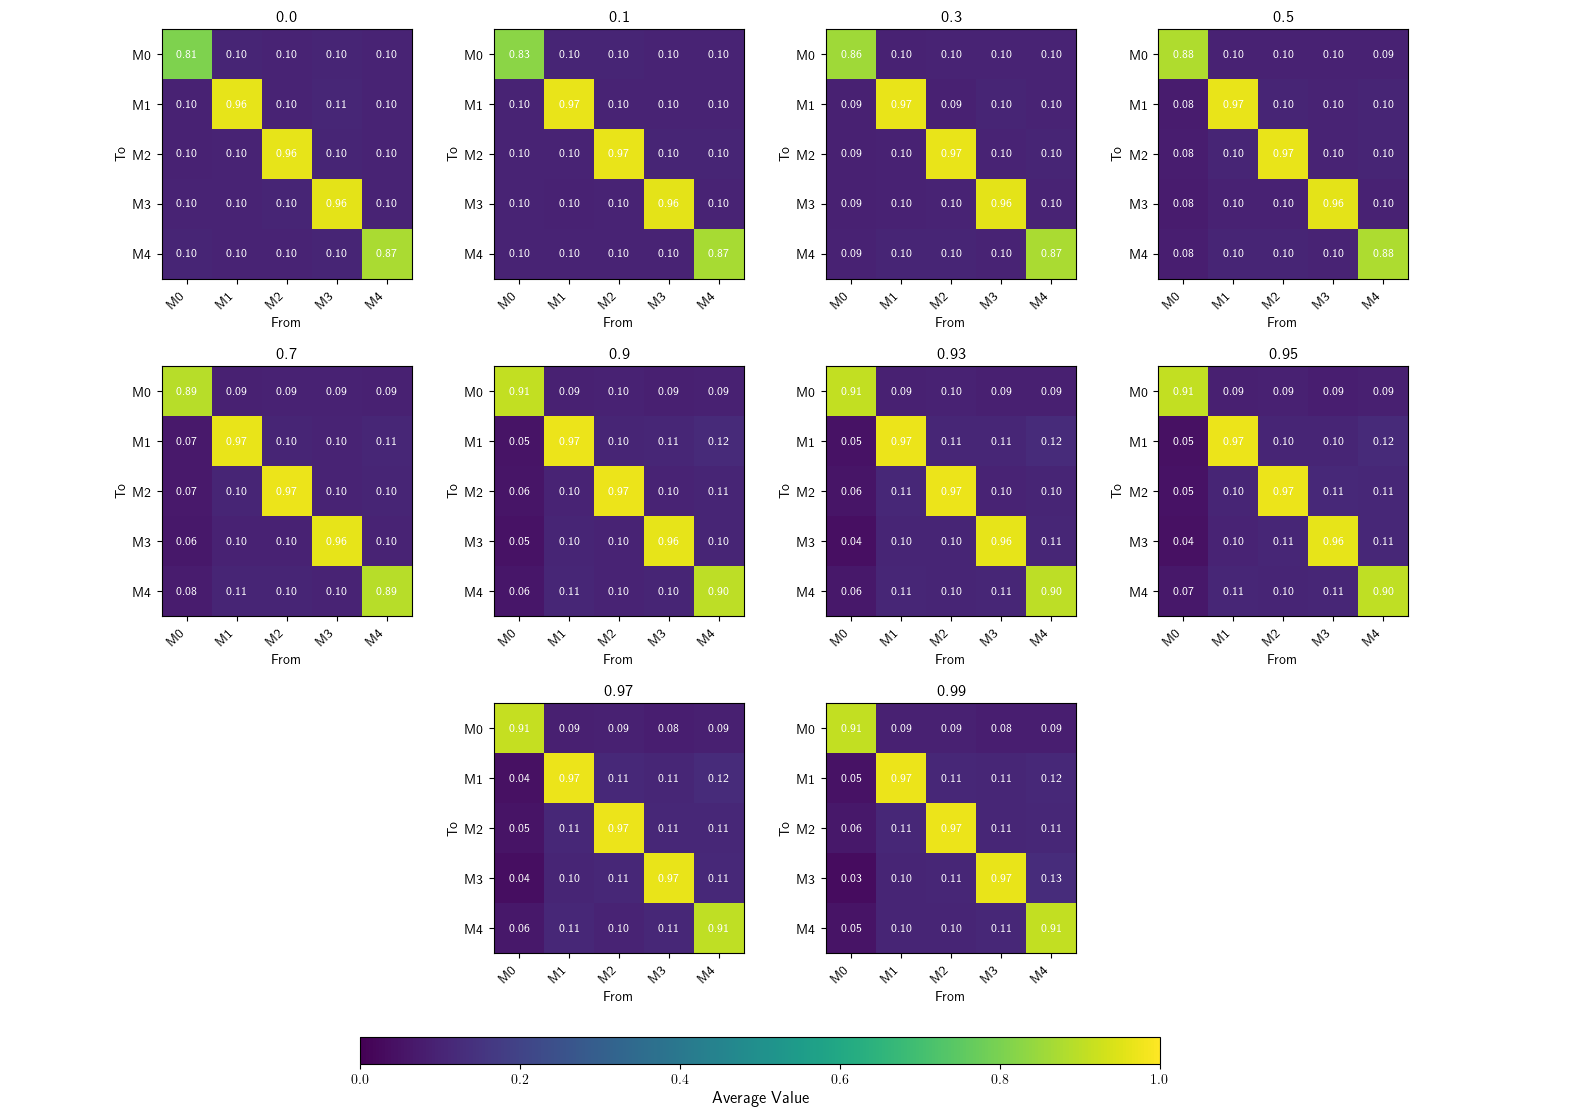

In [182]:
produce_alpha_plots(matrices_jp, "results_figures/alpha_heatmaps.png")

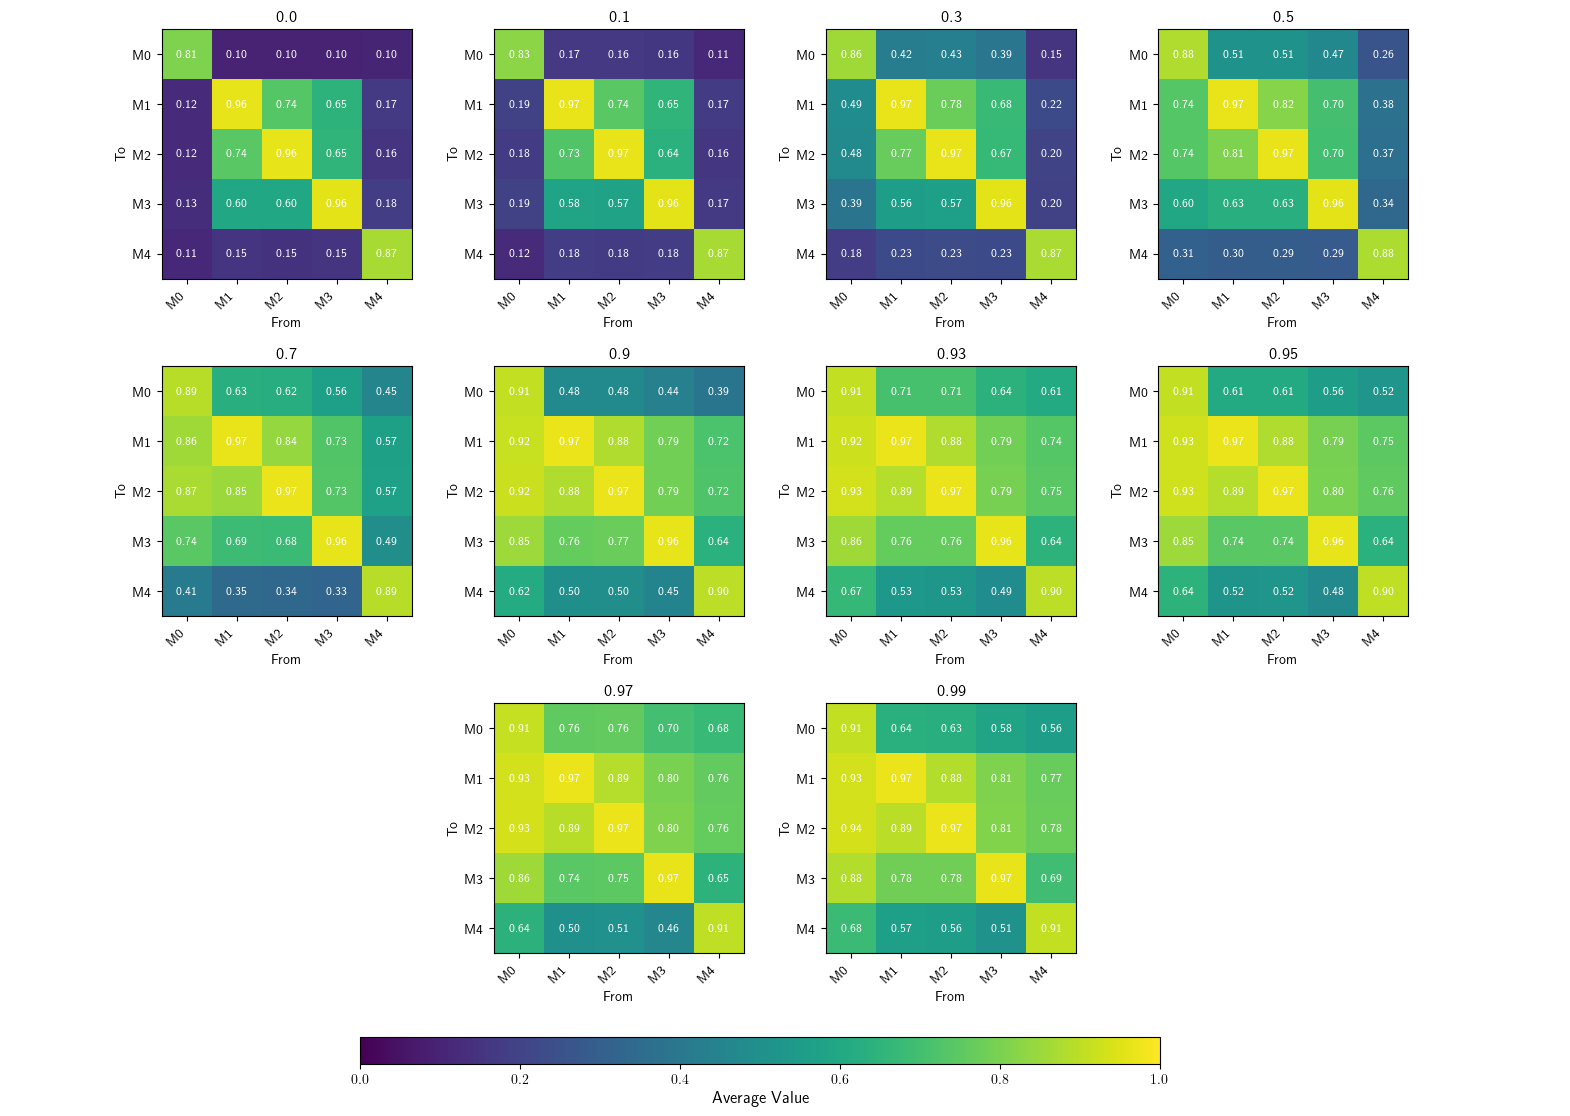

In [183]:
produce_alpha_plots(matrices_jp_cov, "results_figures/alpha_heatmaps_cov.png")

In [184]:
for i, view in enumerate(views):
  cols = ["final_scores/coherence/" + col for col in indiv_results[2 * i + 1]]
  average_name = view + "_average"
  best_name = view + "_best"
  model_means_jp_cov[average_name] = model_means_jp_cov[cols].mean(axis=1)
  model_means_jp_cov[best_name] = model_means_jp_cov[cols].max(axis=1)

model_means_jp_cov['average_overall'] = model_means_jp_cov[[view + "_average" for view in views]].mean(axis=1)
model_means_jp_cov['best_overall'] = model_means_jp_cov[[view + "_best" for view in views]].mean(axis=1)
model_means_jp_cov['average_coherence'] = model_means_jp_cov[["final_scores/coherence/" + view + "_to_" + view + "_cov" for view in views]].mean(axis=1)

In [185]:
cols = ([view + "_average" for view in views])
cols.append('average_overall')
alpha_averages = model_means_jp_cov[cols]
# best
cols = ([view + "_best" for view in views])
cols.append('best_overall')
alpha_best = model_means_jp_cov[cols]
# view-to-view
cols = (["final_scores/coherence/" + view + "_to_" + view + "_cov" for view in views])
cols.append('average_coherence')
view_to_view_averages = model_means_jp_cov[cols]


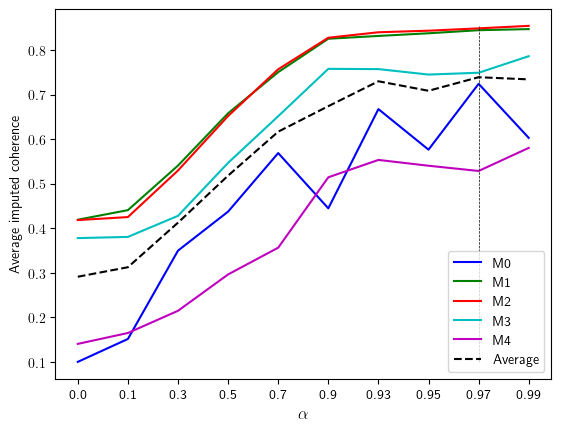

In [186]:
plt.style.use('seaborn-v0_8-colorblind')
legend_names = ["M" + str(i) for i in range(5)]
legend_names.append('Average')
# viridis = mpl.colormaps['viridis'].resampled(6)
cycler = plt.cycler(linestyle=['-', '-', '-', '-', '-', '--'], color='bgrcmk')
fig, ax = plt.subplots()
ax.set_prop_cycle(cycler)
ax.plot(alpha_averages)
ax.set_xlabel(r'$\alpha$', fontsize = 12)
ax.set_ylabel(r'Average imputed coherence')
ax.legend(legend_names, loc='lower right')
ax.vlines(
  np.argmax(model_means_jp_cov['average_overall']),
  np.min(alpha_averages), np.max(alpha_averages), 
  linestyles='dashed', 
  linewidth=0.5,
  colors='k')
plt.savefig('results_figures/average_impute_coherence.png')
plt.show()

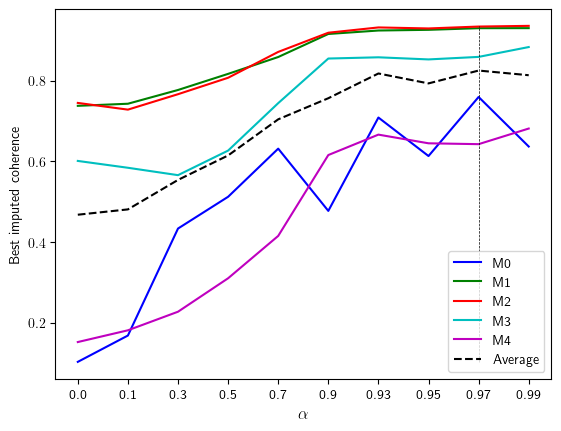

In [187]:
fig, ax = plt.subplots()
ax.set_prop_cycle(cycler)
ax.plot(alpha_best)
ax.set_xlabel(r'$\alpha$', fontsize = 12)
ax.set_ylabel(r'Best imputed coherence')
ax.legend(legend_names, loc='lower right')
ax.vlines(
  np.argmax(model_means_jp_cov['best_overall']),
  np.min(alpha_best), np.max(alpha_best), 
  linestyles='dashed', 
  linewidth=0.5,
  colors='k')
plt.savefig('results_figures/best_impute_coherence.png')
plt.show()

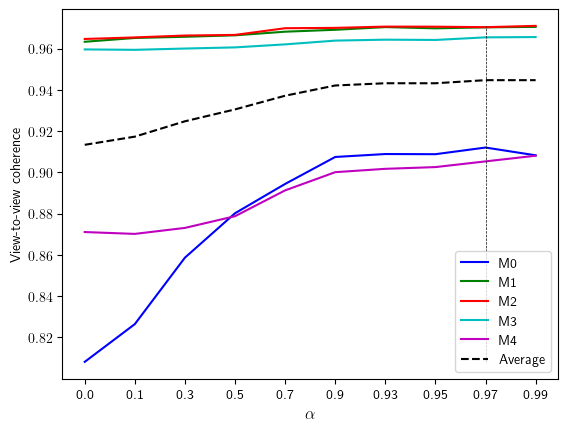

In [188]:
fig, ax = plt.subplots()
ax.set_prop_cycle(cycler)
ax.plot(view_to_view_averages)
ax.set_xlabel(r'$\alpha$', fontsize = 12)
ax.set_ylabel(r'View-to-view coherence')
ax.legend(legend_names, loc='lower right')
ax.vlines(
  np.argmax(model_means_jp_cov['average_coherence']),
  np.min(view_to_view_averages), np.max(view_to_view_averages), 
  linestyles='dashed', 
  linewidth=0.5,
  colors='k')
plt.savefig('results_figures/view_to_view_coherence.png')
plt.show()

We now compare different orderings of modalities.

In [189]:
labels=['independent', 'AVG', 'MoE', 'MoPoE','MMVM','JP']
results_mod = pd.read_csv("wandb_results2.csv")
results_mod["model.alpha_scalar"] = results_mod["model.alpha_scalar"].fillna(0)
results_mod = results_mod[
    ["model.name", "model.aggregation", "model.alpha_scalar", "dataset.modalities_order"] + [col for col in df.columns if "final_scores" in col] 
] 
results_mod["dataset.modalities_order"] = [int(res[0]) if len(res) == 1 else 
                                           int(res[1]) for res in results_mod["dataset.modalities_order"].fillna('0')]
results_mod = results_mod[results_mod["model.name"] == "jointprior"]
results_mod = results_mod[results_mod["model.alpha_scalar"] == 0.97]
results_mod.tail()

,model.name,model.aggregation,model.alpha_scalar,dataset.modalities_order,final_scores/coherence/m0_to_m0,final_scores/coherence/m0_to_m0_cov,final_scores/coherence/m0_to_m1,final_scores/coherence/m0_to_m1_cov,final_scores/coherence/m0_to_m2,final_scores/coherence/m0_to_m2_cov,...,final_scores/downstream_lr/aggregated/m1,final_scores/downstream_lr/aggregated/m2,final_scores/downstream_lr/aggregated/m3,final_scores/downstream_lr/aggregated/m4,final_scores/downstream_lr/unimodal/m0,final_scores/downstream_lr/unimodal/m1,final_scores/downstream_lr/unimodal/m2,final_scores/downstream_lr/unimodal/m3,final_scores/downstream_lr/unimodal/m4,final_scores/rec_loss
32,jointprior,avg,0.97,1,0.881310,0.881210,0.047676,0.725461,0.120393,0.706130,...,0.988782,0.969050,0.954828,0.966046,0.954427,0.988782,0.969050,0.954828,0.966046,5444.801270
33,jointprior,avg,0.97,2,0.877905,0.878005,0.109575,0.712440,0.051983,0.744191,...,0.967248,0.988882,0.954127,0.964944,0.954928,0.967248,0.988882,0.954127,0.964944,5441.184570
42,jointprior,avg,0.97,2,0.874599,0.874800,0.119792,0.697716,0.053786,0.717047,...,0.968149,0.987981,0.957131,0.965044,0.953726,0.968149,0.987981,0.957131,0.965044,5437.690918
54,jointprior,avg,0.97,1,0.877704,0.877804,0.053786,0.735677,0.115284,0.739183,...,0.990084,0.970553,0.956330,0.963041,0.955228,0.990084,0.970553,0.956330,0.963041,5440.296875
63,jointprior,avg,0.97,4,0.884115,0.884215,0.114183,0.730569,0.134615,0.734275,...,0.967047,0.968650,0.950621,0.979567,0.955028,0.967047,0.968650,0.950621,0.979567,5443.284668


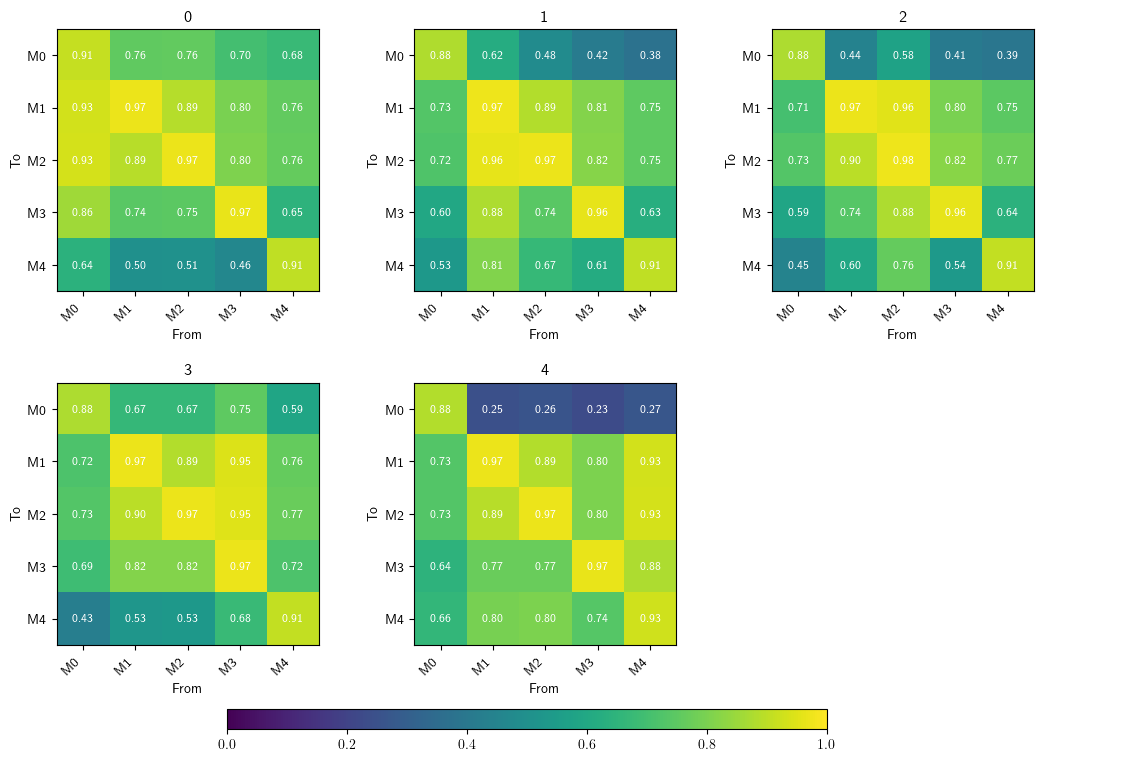

In [190]:
model_means_jp_mod = results_mod.groupby("dataset.modalities_order")[metric_cols_cov].mean()
matrices_jp_mod = {name: extract_matrix(row, True) for name, row in model_means_jp_mod.iterrows()}
produce_plots(matrices_jp_mod, "results_figures/alpha_heatmaps_mod.png", n_rows=2, n_cols=3)

## Heatmaps

In [198]:
# --- Compute averages over repeats for each model ---
df['model.name'] = pd.Categorical(df['model.name'], labels, ordered=True)
df["model.alpha_scalar"] = df["model.alpha_scalar"].fillna(0)
df_subset = df.copy()
df_subset = df_subset[np.logical_or(
  np.logical_and(df_subset["model.alpha_scalar"] == 0.97, 
                 df_subset["dataset.modalities_order"] == 1),
  df_subset["model.alpha_scalar"] == 0
  )]
model_means = df_subset.groupby("model.name", observed=True)[metric_cols].mean()
model_means

,final_scores/coherence/m0_to_m0,final_scores/coherence/m0_to_m1,final_scores/coherence/m0_to_m2,final_scores/coherence/m0_to_m3,final_scores/coherence/m0_to_m4,final_scores/coherence/m1_to_m0,final_scores/coherence/m1_to_m1,final_scores/coherence/m1_to_m2,final_scores/coherence/m1_to_m3,final_scores/coherence/m1_to_m4,...,final_scores/coherence/m3_to_m0,final_scores/coherence/m3_to_m1,final_scores/coherence/m3_to_m2,final_scores/coherence/m3_to_m3,final_scores/coherence/m3_to_m4,final_scores/coherence/m4_to_m0,final_scores/coherence/m4_to_m1,final_scores/coherence/m4_to_m2,final_scores/coherence/m4_to_m3,final_scores/coherence/m4_to_m4
model.name,,,,,,,,,,,,,,,,,,,,,
independent,0.808093,0.096695,0.097336,0.100541,0.101963,0.101703,0.963401,0.101322,0.101502,0.099038,...,0.101783,0.106691,0.101743,0.959595,0.102003,0.100240,0.100481,0.100220,0.098417,0.871194
AVG,0.550000,0.344050,0.353886,0.274519,0.341967,0.685577,0.771554,0.770713,0.520413,0.767989,...,0.655268,0.655429,0.683794,0.842668,0.756691,0.318690,0.351342,0.348157,0.258814,0.440865
MoE,0.780849,0.867728,0.874900,0.852204,0.828165,0.846254,0.899139,0.907171,0.886799,0.858173,...,0.815805,0.864083,0.874239,0.868009,0.814083,0.828566,0.880409,0.888622,0.866567,0.851062
MoPoE,0.700761,0.691086,0.709155,0.684335,0.629547,0.736679,0.860337,0.823077,0.790585,0.719231,...,0.684896,0.745032,0.763401,0.846655,0.650681,0.653966,0.704147,0.720713,0.691887,0.731931
MMVM,0.850200,0.846254,0.853466,0.839383,0.829447,0.809455,0.944311,0.898838,0.879407,0.869010,...,0.795312,0.877123,0.882492,0.944471,0.857432,0.773197,0.855509,0.858954,0.842468,0.885216
JP,0.879507,0.050731,0.117839,0.121444,0.122496,0.058644,0.974509,0.052083,0.025140,0.044271,...,0.117187,0.066106,0.099058,0.964643,0.120693,0.117087,0.065905,0.110827,0.122446,0.905098


In [199]:
model_means_cov = df_subset.groupby("model.name", observed=True)[metric_cols_cov].mean()
model_means_cov

,final_scores/coherence/m0_to_m0_cov,final_scores/coherence/m0_to_m1_cov,final_scores/coherence/m0_to_m2_cov,final_scores/coherence/m0_to_m3_cov,final_scores/coherence/m0_to_m4_cov,final_scores/coherence/m1_to_m0_cov,final_scores/coherence/m1_to_m1_cov,final_scores/coherence/m1_to_m2_cov,final_scores/coherence/m1_to_m3_cov,final_scores/coherence/m1_to_m4_cov,...,final_scores/coherence/m3_to_m0_cov,final_scores/coherence/m3_to_m1_cov,final_scores/coherence/m3_to_m2_cov,final_scores/coherence/m3_to_m3_cov,final_scores/coherence/m3_to_m4_cov,final_scores/coherence/m4_to_m0_cov,final_scores/coherence/m4_to_m1_cov,final_scores/coherence/m4_to_m2_cov,final_scores/coherence/m4_to_m3_cov,final_scores/coherence/m4_to_m4_cov
model.name,,,,,,,,,,,,,,,,,,,,,
independent,0.808153,0.121975,0.119351,0.131951,0.113722,0.099119,0.963341,0.744812,0.597095,0.149499,...,0.101462,0.645994,0.653526,0.959635,0.151583,0.102424,0.171294,0.155869,0.181811,0.871094
AVG,0.536659,0.512179,0.504107,0.493870,0.427524,0.311558,0.767748,0.738582,0.784655,0.682011,...,0.289083,0.708133,0.695994,0.841166,0.635637,0.271514,0.629547,0.620553,0.635877,0.440645
MoE,0.780849,0.801382,0.808954,0.604107,0.767588,0.758474,0.899159,0.828005,0.609896,0.779367,...,0.729307,0.796454,0.800681,0.868129,0.749139,0.752985,0.810096,0.818770,0.610256,0.851122
MoPoE,0.700801,0.618049,0.646254,0.504808,0.571995,0.598217,0.860417,0.772095,0.595673,0.675601,...,0.580909,0.707332,0.728506,0.846655,0.637881,0.530629,0.638742,0.656971,0.514002,0.731931
MMVM,0.850160,0.786038,0.788622,0.696494,0.535998,0.362220,0.944231,0.831090,0.727684,0.556210,...,0.373458,0.822696,0.822456,0.944491,0.565365,0.360757,0.787780,0.789603,0.694111,0.885296
JP,0.879507,0.730569,0.722656,0.597806,0.534756,0.619291,0.974509,0.961088,0.877254,0.809896,...,0.417268,0.814653,0.817959,0.964643,0.614734,0.378255,0.753205,0.751903,0.626903,0.905048


In [200]:
matrices = {name: extract_matrix(row) for name, row in model_means.iterrows()}
matrices_cov = {name: extract_matrix(row, True) for name, row in model_means_cov.iterrows()}

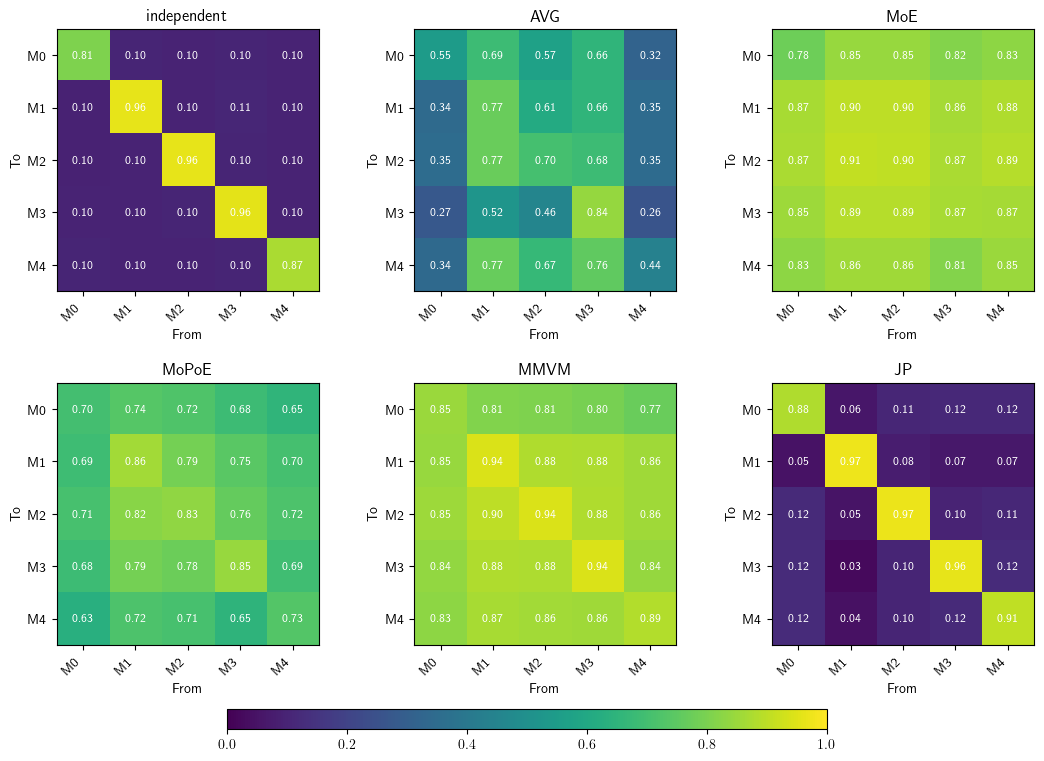

In [201]:
produce_plots(matrices,  "results_figures/methods_heatmaps.png")

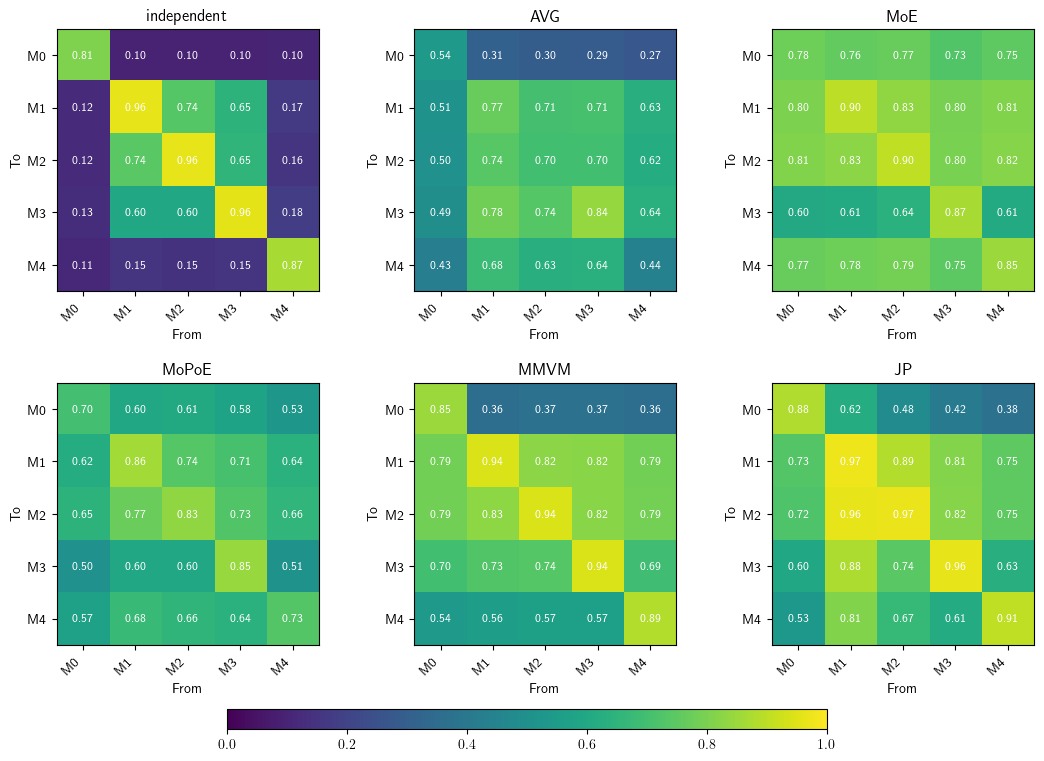

In [202]:
produce_plots(matrices_cov,  "results_figures/methods_heatmaps_cov.png")

In [203]:
matrix_diff = {}
for key in matrices_cov.keys():
  matrix_diff[key] = matrices_cov[key] - matrices[key] 

Investigating the impact of different values of $\alpha$ on the performance of JPVAE.

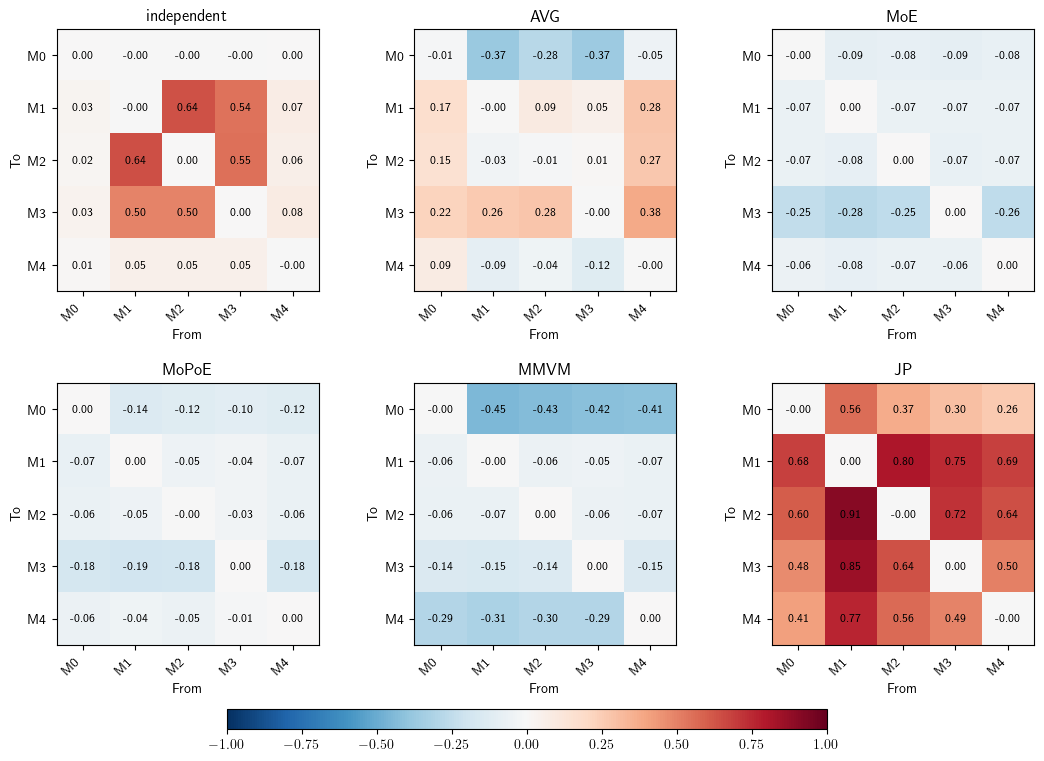

In [204]:
produce_plots(matrix_diff,  "results_figures/methods_heatmaps_diff.png",v_min =-1, color_map='RdBu_r', text_color='k')

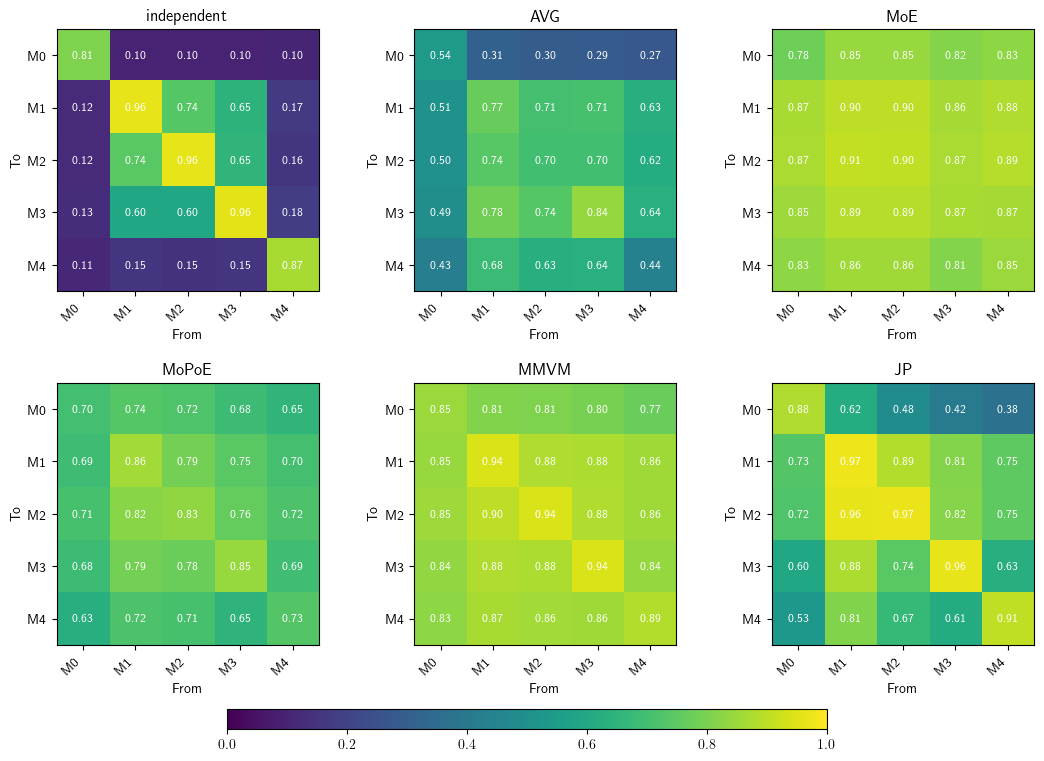

In [205]:
best_results = {
                'independent':matrices_cov['independent'], 
                'AVG':matrices_cov['AVG'],
                'MoE':matrices['MoE'],
                'MoPoE':matrices['MoPoE'],
                'MMVM':matrices['MMVM'],
                'JP':matrices_cov['JP']
                }
produce_plots(best_results,  "results_figures/methods_heatmaps_best.png")

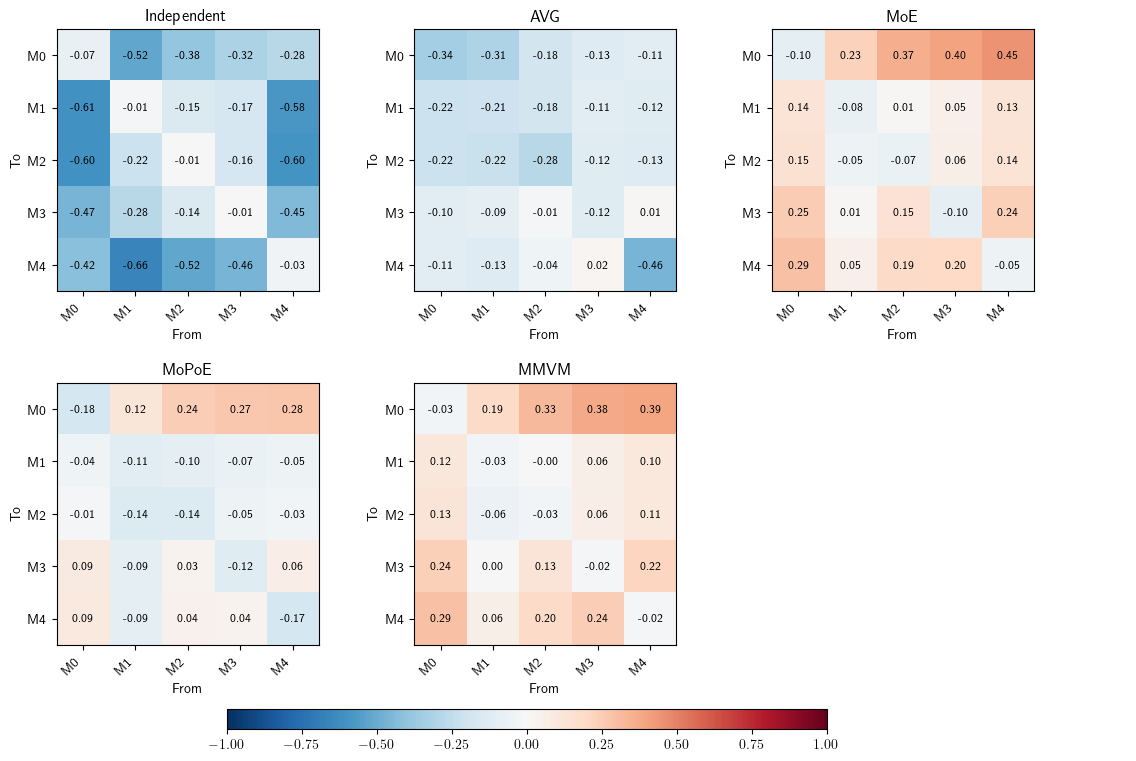

In [207]:
best_results = {'Independent':matrices_cov['independent']-matrices_cov['JP'],
                'AVG':matrices_cov['AVG']-matrices_cov['JP'],
                'MoE':matrices['MoE']-matrices_cov['JP'],
                'MoPoE':matrices['MoPoE']-matrices_cov['JP'],
                'MMVM':matrices['MMVM']-matrices_cov['JP']
                }
produce_plots(best_results,  "results_figures/methods_heatmaps_best.png", v_min=-1, color_map='RdBu_r', text_color='k', n_cols=3, n_rows=2)

In [208]:
model_map = {'AVG':1, "JP":1, "independent":1, "MMVM":0, "MoPoE":0, "MoE":0}
df_subset["covariance"] = df_subset["model.name"].map(model_map)


for view_a in views:
  var_name = view_a + "_to_" + view_a
  df_subset["coh/" + var_name] = np.where(df_subset["covariance"],
                                   df_subset["final_scores/coherence/" + var_name + "_cov"],
                                   df_subset["final_scores/coherence/" + var_name])
  for view_b in views:
    var_name2 = view_a + "_to_" + view_b
    df_subset["coh/" + var_name2] = np.where(df_subset["covariance"],
                                   df_subset["final_scores/coherence/" + var_name2 + "_cov"],
                                   df_subset["final_scores/coherence/" + var_name2])
    
df_subset.head()

,model.name,model.aggregation,model.alpha_scalar,dataset.modalities_order,final_scores/coherence/m0_to_m0,final_scores/coherence/m0_to_m0_cov,final_scores/coherence/m0_to_m1,final_scores/coherence/m0_to_m1_cov,final_scores/coherence/m0_to_m2,final_scores/coherence/m0_to_m2_cov,...,coh/m3_to_m3,coh/m3_to_m0,coh/m3_to_m1,coh/m3_to_m2,coh/m3_to_m4,coh/m4_to_m4,coh/m4_to_m0,coh/m4_to_m1,coh/m4_to_m2,coh/m4_to_m3
1,MoE,moe,0.0,0,0.778245,0.778345,0.879607,0.838041,0.877504,0.811498,...,0.868389,0.821615,0.875701,0.881010,0.819511,0.857873,0.837841,0.889523,0.891627,0.879507
6,MoE,moe,0.0,0,0.757212,0.757111,0.855369,0.795272,0.864684,0.795373,...,0.859776,0.810296,0.863682,0.868890,0.839643,0.858073,0.821715,0.876703,0.885216,0.855869
7,MoE,moe,0.0,0,0.803385,0.803285,0.881210,0.813201,0.888722,0.825321,...,0.879207,0.815104,0.868289,0.871795,0.797476,0.841446,0.829928,0.882612,0.890525,0.864684
13,MoE,moe,0.0,0,0.790365,0.790465,0.862881,0.746394,0.877003,0.775841,...,0.872796,0.820813,0.858073,0.882212,0.793670,0.858574,0.830829,0.886018,0.896434,0.880809
14,MoE,moe,0.0,0,0.775040,0.775040,0.859575,0.814002,0.866587,0.836739,...,0.859876,0.811198,0.854667,0.867288,0.820112,0.839343,0.822516,0.867188,0.879307,0.851963


In [209]:
for i, view in enumerate(views):
  cols = ["coh/" + col for col in indiv_results[2 * i]]
  average_name = view + "_average"
  best_name = view + "_best"
  df_subset[average_name] = df_subset[cols].mean(axis=1)
  df_subset[best_name] = df_subset[cols].max(axis=1)

df_subset['average_overall'] = df_subset[[view + "_average" for view in views]].mean(axis=1)
df_subset['best_overall'] = df_subset[[view + "_best" for view in views]].mean(axis=1)
df_subset['average_coherence'] = df_subset[["coh/" + view + "_to_" + view for view in views]].mean(axis=1)
df_subset.head()

,model.name,model.aggregation,model.alpha_scalar,dataset.modalities_order,final_scores/coherence/m0_to_m0,final_scores/coherence/m0_to_m0_cov,final_scores/coherence/m0_to_m1,final_scores/coherence/m0_to_m1_cov,final_scores/coherence/m0_to_m2,final_scores/coherence/m0_to_m2_cov,...,m1_best,m2_average,m2_best,m3_average,m3_best,m4_average,m4_best,average_overall,best_overall,average_coherence
1,MoE,moe,0.0,0,0.778245,0.778345,0.879607,0.838041,0.877504,0.811498,...,0.906350,0.888572,0.904147,0.883238,0.899539,0.842223,0.858774,0.868429,0.884355,0.862460
6,MoE,moe,0.0,0,0.757212,0.757111,0.855369,0.795272,0.864684,0.795373,...,0.898438,0.883388,0.914764,0.864583,0.892929,0.858749,0.887620,0.861924,0.889223,0.857051
7,MoE,moe,0.0,0,0.803385,0.803285,0.881210,0.813201,0.888722,0.825321,...,0.893329,0.887495,0.898938,0.871094,0.880809,0.827799,0.843349,0.859585,0.872336,0.861138
13,MoE,moe,0.0,0,0.790365,0.790465,0.862881,0.746394,0.877003,0.775841,...,0.897035,0.891401,0.909956,0.879207,0.894832,0.809846,0.826422,0.858398,0.874940,0.865365
14,MoE,moe,0.0,0,0.775040,0.775040,0.859575,0.814002,0.866587,0.836739,...,0.904547,0.880308,0.908053,0.870267,0.894531,0.858148,0.885517,0.863467,0.890845,0.857232


In [210]:
df_subset[["model.name", "final_scores/coherence/m0_to_m4_cov"]]

,model.name,final_scores/coherence/m0_to_m4_cov
1,MoE,0.735677
6,MoE,0.750401
7,MoE,0.806991
13,MoE,0.759515
14,MoE,0.785357
26,MoPoE,0.606671
28,MoPoE,0.649239
31,MoPoE,0.467448
32,JP,0.505409
34,MoPoE,0.574419


In [211]:
for i, view in enumerate(views):
  cols = ["coh/" + col for col in indiv_results[2 * i]]
  cols.append("final_scores/coherence/" + view + "_to_" + view)
  average_name = view + "_average_inc_view"
  df_subset[average_name] = df_subset[cols].mean(axis=1)

df_subset['average_overall_inc_view'] = df_subset[[view + "_average_inc_view" for view in views]].mean(axis=1)
df_subset.head()

,model.name,model.aggregation,model.alpha_scalar,dataset.modalities_order,final_scores/coherence/m0_to_m0,final_scores/coherence/m0_to_m0_cov,final_scores/coherence/m0_to_m1,final_scores/coherence/m0_to_m1_cov,final_scores/coherence/m0_to_m2,final_scores/coherence/m0_to_m2_cov,...,m4_best,average_overall,best_overall,average_coherence,m0_average_inc_view,m1_average_inc_view,m2_average_inc_view,m3_average_inc_view,m4_average_inc_view,average_overall_inc_view
1,MoE,moe,0.0,0,0.778245,0.778345,0.879607,0.838041,0.877504,0.811498,...,0.858774,0.868429,0.884355,0.862460,0.827905,0.890445,0.892208,0.880268,0.845353,0.867236
6,MoE,moe,0.0,0,0.757212,0.757111,0.855369,0.795272,0.864684,0.795373,...,0.887620,0.861924,0.889223,0.857051,0.814924,0.880188,0.887400,0.863622,0.858614,0.860950
7,MoE,moe,0.0,0,0.803385,0.803285,0.881210,0.813201,0.888722,0.825321,...,0.843349,0.859585,0.872336,0.861138,0.824820,0.883053,0.888361,0.872716,0.830529,0.859896
13,MoE,moe,0.0,0,0.790365,0.790465,0.862881,0.746394,0.877003,0.775841,...,0.826422,0.858398,0.874940,0.865365,0.826502,0.880349,0.894591,0.877925,0.819591,0.859792
14,MoE,moe,0.0,0,0.775040,0.775040,0.859575,0.814002,0.866587,0.836739,...,0.885517,0.863467,0.890845,0.857232,0.824700,0.877264,0.886558,0.868189,0.854387,0.862220


In [213]:
  # Keep only the relevant columns
cols_avg = [view + "_average" for view in views]
cols_avg.append('average_overall')
cols_avg_inc_views = [view + "_average_inc_view" for view in views]
cols_avg_inc_views.append('average_overall_inc_view')
cols_best = [view + "_best" for view in views]
cols_best.append('best_overall')
cols_view_to_view = ["coh/" + view + "_to_" + view for view in views]
cols_view_to_view.append("average_coherence")

In [214]:
columns = df_subset.columns

In [215]:
agg_cols = [col for col in columns if "final_scores/downstream_lr/aggregated" in col]
uni_cols = [col for col in columns if "final_scores/downstream_lr/unimodal" in col]

In [216]:
df_subset['unimodal_average'] = df_subset[uni_cols].mean(axis=1)
df_subset['agg_average'] = df_subset[agg_cols].mean(axis=1)
uni_cols.append('unimodal_average')
agg_cols.append("agg_average")

In [217]:
main_cols = [cols[-1] for cols in [cols_avg, cols_best, cols_view_to_view, uni_cols, agg_cols]]

In [219]:
def coherence_plots(df, cols_to_use, x_title, title, file_path, combination_plot = False):
  cols = cols_to_use.copy()
  cols.append("model.name")
  df_subset = df[cols]

  # Melt into long format for grouped plotting
  df_long = df_subset.melt(id_vars="model.name", 
                          var_name="metric", 
                          value_name="score")
  df_long["metric"] = df_long["metric"].str.replace("_average", "", regex=False)
  if combination_plot:
    df_long["metric"] = df_long["metric"].str.replace("unimodal", "LR (unimodal)", regex=False)
    df_long["metric"] = df_long["metric"].str.replace("agg", "LR (aggregation)", regex=False)
    df_long["metric"] = df_long["metric"].str.replace("average_overall", "Coherence (average)", regex=False)
    df_long["metric"] = df_long["metric"].str.replace("best_overall", "Coherence (best)", regex=False)
    df_long["metric"] = df_long["metric"].str.replace("average_coherence", "Coherence (view to view)", regex=False)
  else:
    df_long["metric"] = df_long["metric"].str.replace("coh/", "", regex=False)
    df_long["metric"] = df_long["metric"].str.replace("_best", "", regex=False)
    
    df_long["metric"] = df_long["metric"].str.replace("best_o", "O", regex=False)
    df_long["metric"] = df_long["metric"].str.replace("average_o", "O", regex=False)
    df_long["metric"] = df_long["metric"].str.replace("final_scores/downstream_lr/", "", regex=False)
    df_long["metric"] = df_long["metric"].str.replace("unimodal/", "", regex=False)
    df_long["metric"] = df_long["metric"].str.replace("aggregated/", "", regex=False)
    df_long["metric"] = df_long["metric"].str.replace("_inc_view", "", regex=False)
    df_long["metric"] = df_long["metric"].str.replace("unimodal", "Overall", regex=False)
    df_long["metric"] = df_long["metric"].str.replace("agg", "Overall", regex=False)
    df_long["metric"] = df_long["metric"].str.replace("average_coherence", "Overall", regex=False)
    df_long["metric"] = df_long["metric"].str.replace("m", "M", regex=False)  
  
  # Compute mean and SEM by model + metric
  summary = (
      df_long.groupby(["model.name", "metric"], observed=True)
      .agg(mean=("score", "mean"), sem=("score", "sem"))
      .reset_index()
  )
  # Pivot so we can plot grouped bars
  metrics = summary["metric"].unique()
  models = summary["model.name"].unique()
  x = summary["model.name"].unique()
  x = np.arange(len(metrics))
  # bar_width = 0.25
  bar_width = 0.8 / len(metrics)
  if combination_plot:
    bar_width = 0.8 / (len(metrics) + 1)

  fig, ax = plt.subplots(figsize=(10,6))

  # Plot each metric as a group
  for i, model in enumerate(models):
      data = summary[summary["model.name"] == model]
      ax.bar(
          x + i * bar_width,
          data.set_index("metric").loc[metrics, "mean"],
          yerr=data.set_index("metric").loc[metrics, "sem"],
          # color=colors[i],
          width=bar_width,
          label=model,
          capsize=4
      )

  # Formatting
  ax.set_xlim(-0.25)
  ax.set_xticks(x + bar_width * (len(models)-1)/2)
  ax.set_xticklabels(metrics)
  ax.set_ylabel("Mean Score (± SE)")
  ax.set_xlabel(x_title)
  ax.set_title(title)
  ax.legend(title="Model", loc = "lower right")

  plt.tight_layout()
  plt.savefig(file_path)

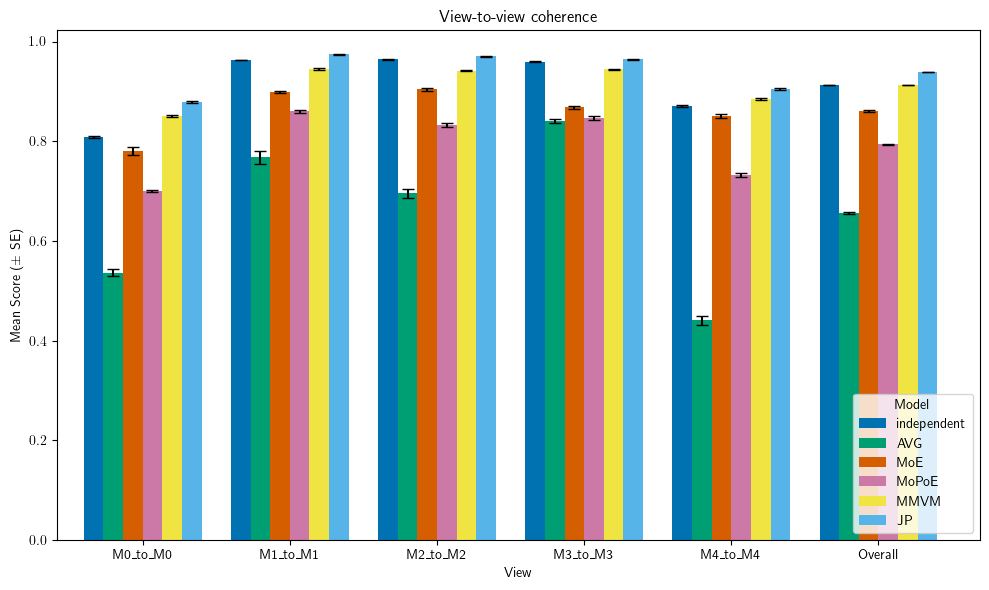

In [220]:
coherence_plots(df_subset, cols_view_to_view, "View", "View-to-view coherence", "results_figures/view_to_view_coherence_barplot.png")

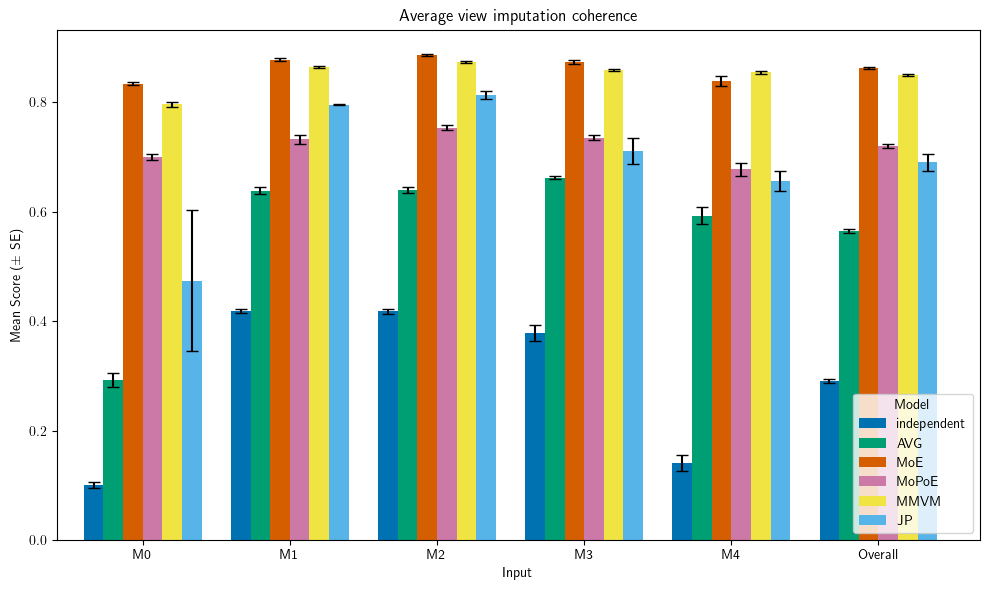

In [221]:
coherence_plots(df_subset, cols_avg, "Input", "Average view imputation coherence", "results_figures/average_imputation_coherence_barplot.png")

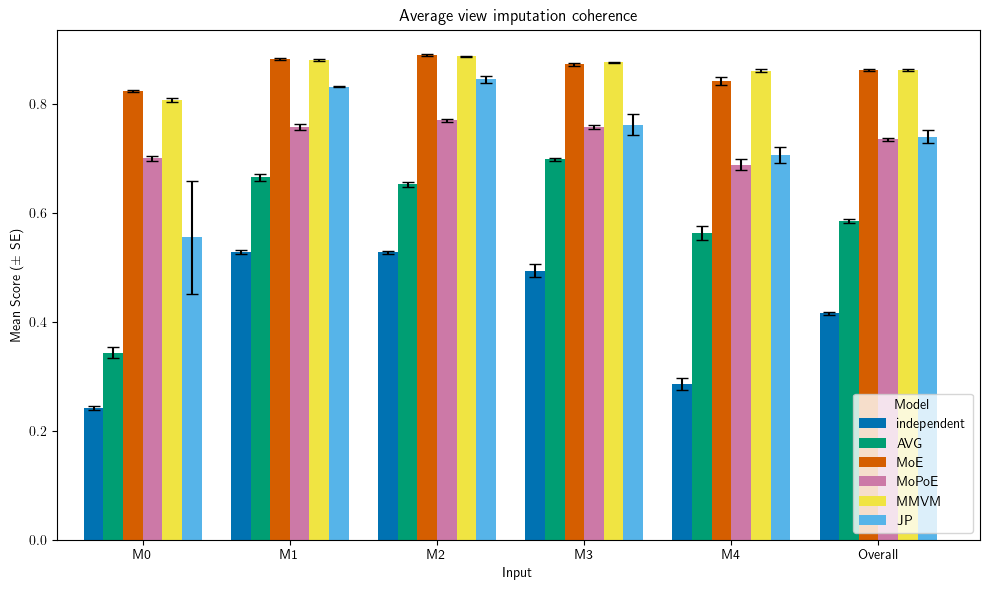

In [223]:
coherence_plots(df_subset, cols_avg_inc_views, "Input", "Average view imputation coherence", "results_figures/average_imputation_coherence_inc_views_barplot.png")

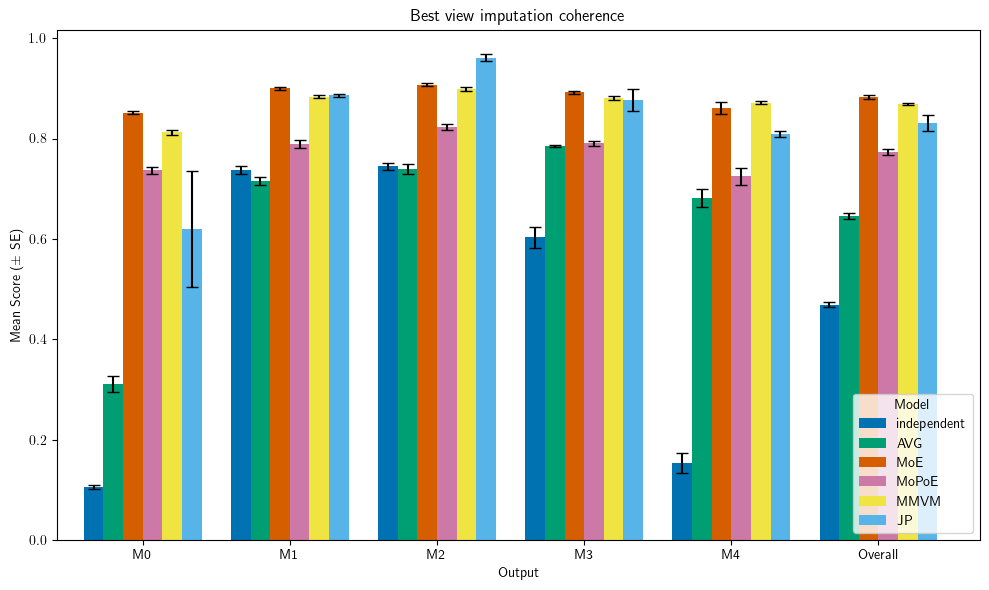

In [224]:
coherence_plots(df_subset, cols_best, "Output", "Best view imputation coherence", "results_figures/best_imputation_coherence_barplot.png")

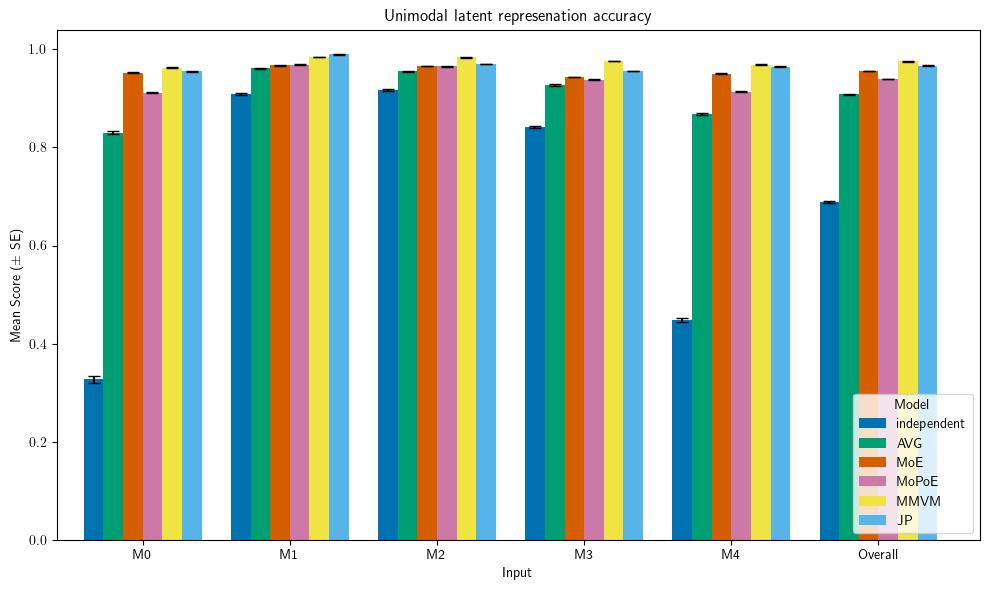

In [225]:
coherence_plots(df_subset, uni_cols, "Input", "Unimodal latent represenation accuracy", "results_figures/unimodal_barplot.png")

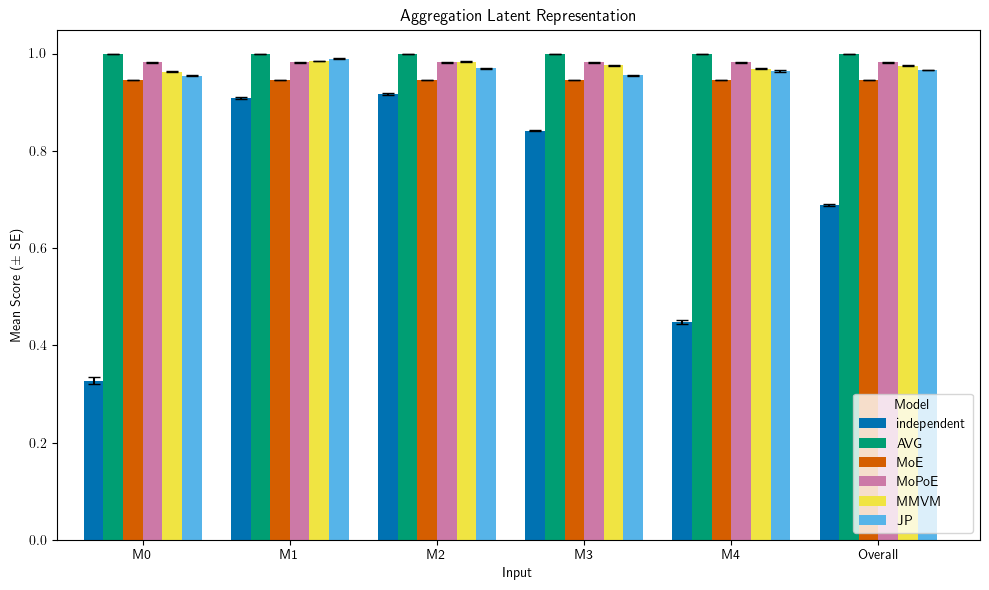

In [226]:
coherence_plots(df_subset, agg_cols, "Input", "Aggregation Latent Representation", "results_figures/agg_barplot.png")

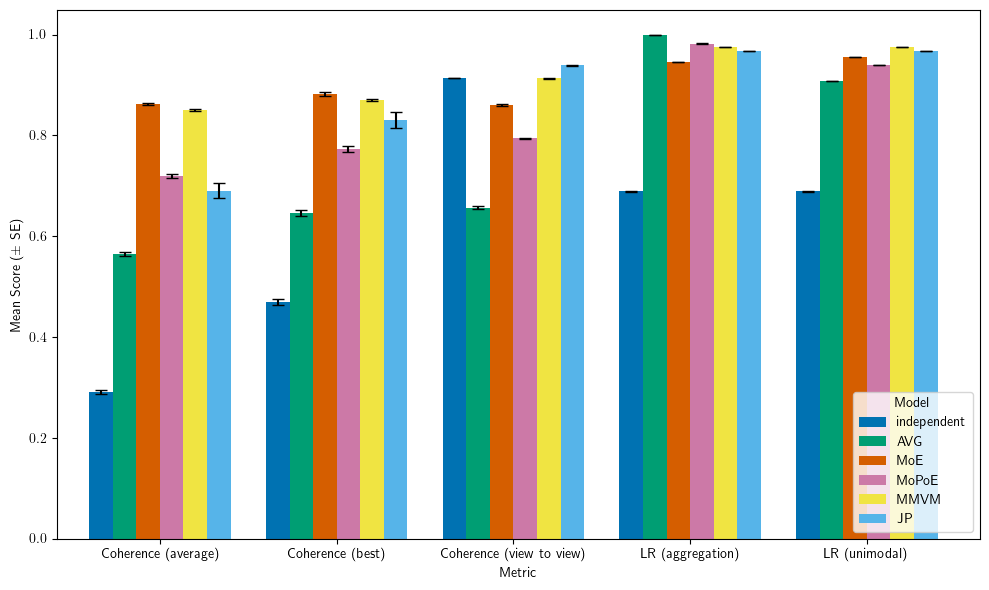

In [227]:
coherence_plots(df_subset, main_cols, "Metric", "", "results_figures/combined_results.png", combination_plot=True)

In [228]:
def two_axis_plot(df, filepath):
  _, axes = plt.subplots(2, 2, figsize=(10,8))
  axes = np.array(axes).reshape(-1)  
  y_axes = ['average_overall', 'best_overall', "agg_average", "unimodal_average"]
  y_titles =["Coherence (average)", "Coherence (best)",
             "Coherence (aggregation)", "LR (unimodal)"]
  for ax, y_axis, y_title in zip(axes, y_axes, y_titles):
    for model, group in df.groupby('model.name', observed=False):
        ax.scatter(
            group["final_scores/rec_loss"],
            group[y_axis],
            label=model,
            alpha=0.8
        )
    ax.set_xlabel("Reconstruction loss", fontsize=10)
    ax.set_ylabel(y_title, fontsize=10)
    if y_title == "LR (unimodal)":
      handles, labels = ax.get_legend_handles_labels()
      by_label = dict(zip(labels, handles))
      ax.legend(by_label.values(), by_label.keys(), title="Model", 
                loc =(0.6, 0.1), scatterpoints=1)
  
  plt.savefig(filepath)
  plt.show()

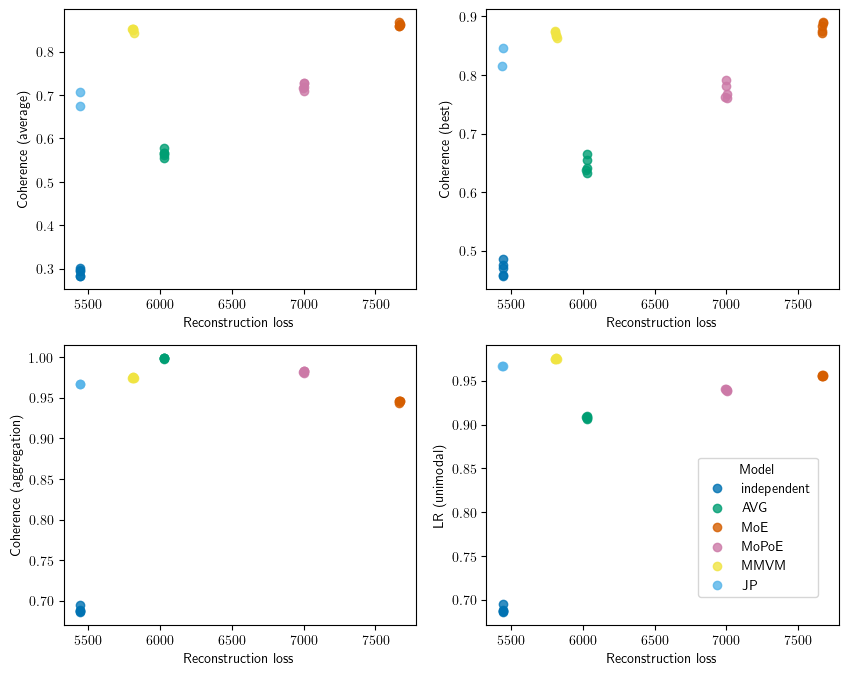

In [229]:
two_axis_plot(df_subset, "results_figures/recon_loss_plots.png")